# Tabular Kaggle Project



## Project Link

https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction

## Challenge

This project focuses on predicting whether an airline passenger is **satisfied** or **neutral or dissatisfied** based on passenger information, travel details, service ratings, and delay-related variables.

In addition to building a classification model, I want to understand which airline service features are most strongly **associated with** passenger dissatisfaction. I am especially interested in factors such as **online boarding, inflight wifi service, seat comfort, inflight entertainment, cleanliness, food and drink, leg room service, and delay-related measures**.

The goal is to identify the features that appear most important for predicting satisfaction and to highlight service areas that airlines may want to improve.

## Data Description

The dataset is an airline passenger satisfaction survey from Kaggle. It includes passenger information such as **gender, age, customer type, type of travel, class, and flight distance**, along with service-related features such as **inflight wifi service, departure/arrival time convenience, ease of online booking, gate location, food and drink, online boarding, seat comfort, inflight entertainment, on-board service, leg room service, baggage handling, check-in service, inflight service, cleanliness, departure delay in minutes, and arrival delay in minutes**.

The target variable is **satisfaction**, which has two classes: **neutral or dissatisfied** and **satisfied**. This makes the project a **binary classification** problem.

## Data Loading and Initial Look

* Load the data. 
* Count the number of rows (data points) and features.
* Any missing values? 
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values? 
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

In [117]:
import pandas as pd
import numpy as np
data = pd.read_csv("train.csv")

In [118]:
# Removing The Redundant Column, I remove The {Unnamed: 0} column because it is just an index 
# and does not provide any useful information for our analysis.
data = data.drop(columns=["Unnamed: 0"], errors="ignore")
print(data.columns)

Index(['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')


In [119]:
# Creating a Basic Summary Table
# Note: Our target variable is "Satisfaction" for future reference.
summary_rows = []

for column in data.columns:
    
    # Decide if the column is categorical or numerical
    if data[column].dtype == "object":
        column_type = "Categorical"
        values_or_range = ", ".join(data[column].unique())
    else:
        column_type = "Numerical"
        values_or_range = str(data[column].min()) + " to " + str(data[column].max())
    
    # Count missing values
    missing_count = data[column].isnull().sum()
    
    # Count unique values
    unique_count = data[column].nunique()
    
    # Add the information to the summary list
    summary_rows.append({
        "Column Name": column,
        "Type": column_type,
        "Values or Range": values_or_range,
        "Missing Values": missing_count,
        "Number of Unique Values": unique_count
    })

# Convert the list into a DataFrame/table
summary_table = pd.DataFrame(summary_rows)

summary_table

,Column Name,Type,Values or Range,Missing Values,Number of Unique Values
0,id,Numerical,1 to 129880,0,103904
1,Gender,Categorical,"Male, Female",0,2
2,Customer Type,Categorical,"Loyal Customer, disloyal Customer",0,2
3,Age,Numerical,7 to 85,0,75
4,Type of Travel,Categorical,"Personal Travel, Business travel",0,2
5,Class,Categorical,"Eco Plus, Business, Eco",0,3
6,Flight Distance,Numerical,31 to 4983,0,3802
7,Inflight wifi service,Numerical,0 to 5,0,6
8,Departure/Arrival time convenient,Numerical,0 to 5,0,6
9,Ease of Online booking,Numerical,0 to 5,0,6


### Table Summary

The dataset contains passenger details, travel information, service ratings, delay information, and the target variable **satisfaction**.

Most columns have no missing values. The only column with missing data is **Arrival Delay in Minutes**, which has **310 missing values**.

The dataset includes categorical features such as **Gender**, **Customer Type**, **Type of Travel**, and **Class**. It also includes numerical features such as **Age**, **Flight Distance**, service ratings, and delay columns.

The target variable is **satisfaction**, with two classes: **neutral or dissatisfied** and **satisfied**, so this is a binary classification problem.

In [120]:
# Now Lets Check for Duplicate rows as well :) 
duplicate_rows = data.duplicated().sum() 
print(f"Number of duplicate rows: {duplicate_rows}")
# Seems like there are no duplicate rows in the dataset, which is good for our analysis.

Number of duplicate rows: 0


## Handling the missing values

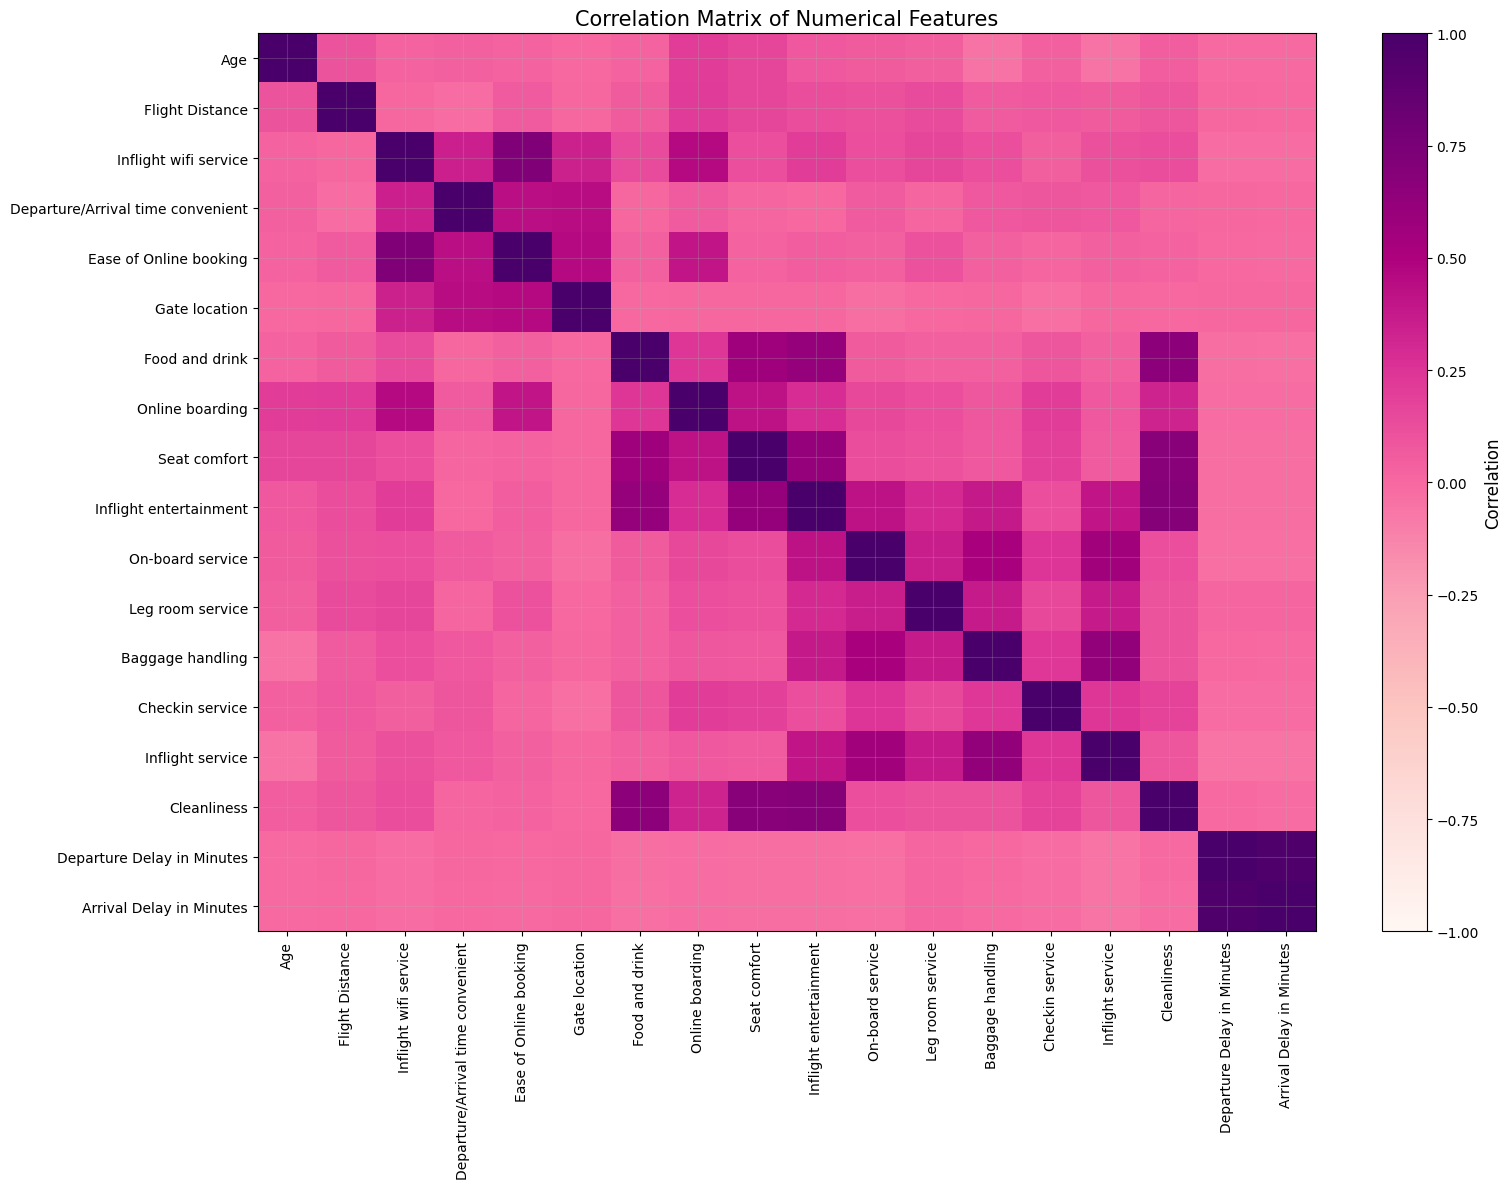

In [121]:
# Okay, I know that visualizing come a little later according the templeate but I need the corolation, 
# so I can fill in the missing values. :)
# So this is the code to check, the relationship between numerical features using a correlation map
import matplotlib.pyplot as plt

# Select only numerical columns
numerical_data = data.select_dtypes(include=["int64", "float64"])

# Remove id from the correlation map because it is just an identification number
numerical_data = numerical_data.drop(columns=["id"], errors="ignore")

# Create the correlation matrix
correlation_matrix = numerical_data.corr()

# Make the correlation heatmap
plt.figure(figsize=(16, 12))

plt.imshow(correlation_matrix, aspect="auto", vmin=-1, vmax=1, cmap="RdPu")
plt.colorbar(label="Correlation")

# Add column names as labels
plt.xticks(
    np.arange(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    np.arange(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

## Plan for Handling Missing Arrival Delay Values

The only column with missing values is **Arrival Delay in Minutes**, with **310 missing values**.

Before filling these values, I checked the relationship between **Departure Delay in Minutes** and **Arrival Delay in Minutes**. The correlation between the two columns is about **0.97**, which shows a very strong positive relationship.

Because of this strong relationship, I decided not to delete the rows with missing arrival delays. Instead, for each missing arrival delay value, I used rows with very similar departure delay values and filled the missing value using the average arrival delay of the three closest matching rows.

I also checked whether the closest departure delay values were actually close. The results showed that none of the third-closest values were more than 5 minutes away, so this method was reasonable for this dataset.

In [122]:
# Check how close the 3 closest departure delay values are
# for the rows where Arrival Delay is missing.

arrival_delay_list = list(data["Arrival Delay in Minutes"])
departure_delay_list = list(data["Departure Delay in Minutes"])

third_closest_distances = []

for i in range(len(arrival_delay_list)):

    # Only look at rows where Arrival Delay is missing
    if pd.isnull(arrival_delay_list[i]):

        current_departure_delay = departure_delay_list[i]
        distances = []

        # Compare to rows where Arrival Delay is known
        for j in range(len(arrival_delay_list)):

            if pd.notnull(arrival_delay_list[j]):

                difference = abs(departure_delay_list[j] - current_departure_delay)
                distances.append(difference)

        # Sort from smallest difference to biggest difference
        distances.sort()

        # Save the distance of the 3rd closest row
        third_closest_distances.append(distances[2])

# Turn it into a small summary
distance_check = pd.Series(third_closest_distances)

print("Summary of distance to the 3rd closest departure delay:\n", distance_check.describe())

print("\nNumber of missing rows where the 3rd closest value is more than 5 minutes away:", (distance_check > 5).sum())

print("\nNumber of missing rows where the 3rd closest value is more than 10 minutes away:", (distance_check > 10).sum())

Summary of distance to the 3rd closest departure delay:
 count    310.000000
mean       0.009677
std        0.126836
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        2.000000
dtype: float64

Number of missing rows where the 3rd closest value is more than 5 minutes away: 0

Number of missing rows where the 3rd closest value is more than 10 minutes away: 0


For every row where Arrival Delay is missing:
    Look at that row's Departure Delay.
    Compare it to all other rows where Arrival Delay is known.
    Find the 3 closest Departure Delay values.
    Save how far away the 3rd closest one is.

In [123]:
# Okay, Since the 3rd closest departure delay is usually pretty close, we can use it to fill in the missing arrival delay values.
arrival_delay_list = list(data["Arrival Delay in Minutes"])
departure_delay_list = list(data["Departure Delay in Minutes"])

# Go through every row
for i in range(len(arrival_delay_list)):

    # Check if Arrival Delay is missing
    if pd.isnull(arrival_delay_list[i]):

        current_departure_delay = departure_delay_list[i]

        closest_values = []

        # Compare this row's departure delay to other rows
        for j in range(len(arrival_delay_list)):

            # Only use rows where Arrival Delay is known
            if pd.notnull(arrival_delay_list[j]):

                difference = abs(departure_delay_list[j] - current_departure_delay)

                closest_values.append([
                    difference,
                    arrival_delay_list[j]
                ])

        # Sort so the closest departure delays come first
        closest_values.sort()

        # Take the 3 closest known arrival delays
        top_3 = closest_values[:3]

        # Average those 3 arrival delay values
        total = 0

        for value in top_3:
            total = total + value[1]

        average_arrival_delay = total / len(top_3)

        # Fill the missing value in the list
        arrival_delay_list[i] = average_arrival_delay

# Replace the column with the completed list
data["Arrival Delay in Minutes"] = arrival_delay_list

# Check if missing values are gone
print("Missing Arrival Delay values after filling:", data["Arrival Delay in Minutes"].isnull().sum())


Missing Arrival Delay values after filling: 0


## Outliers Check
For this project I am going to use the IQR methode to check the outlires. 


In [124]:
# Check for outliers using the IQR method,
columns_to_check = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

outlier_rows = []

for column in columns_to_check:
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) | 
        (data[column] > upper_bound)
    ]
    
    outlier_rows.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Outliers": len(outliers)
    })

outlier_table = pd.DataFrame(outlier_rows)

outlier_table

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers
0,Age,27.0,51.0,24.0,-9.0,87.0,0
1,Flight Distance,414.0,1743.0,1329.0,-1579.5,3736.5,2291
2,Departure Delay in Minutes,0.0,12.0,12.0,-18.0,30.0,14529
3,Arrival Delay in Minutes,0.0,13.0,13.0,-19.5,32.5,14022


In [125]:
# Seem like there are alot of outliers in the dataset, but I am not going to remove them because they might be important for our analysis. 
# Lets see if we can keep them :)
# Look at the basic summary for the columns with possible outliers

outlier_columns = [
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

data[outlier_columns].describe()


,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000
mean,1189.448375,14.815618,15.207827
std,997.147281,38.230901,38.774520
min,31.000000,0.000000,0.000000
25%,414.000000,0.000000,0.000000
50%,843.000000,0.000000,0.000000
75%,1743.000000,12.000000,13.000000
max,4983.000000,1592.000000,1584.000000


### Outlier Summary

Using the IQR method, I found many outliers in **Flight Distance**, **Departure Delay in Minutes**, and **Arrival Delay in Minutes**.

The delay columns had the most outliers. This makes sense because most flights have little or no delay, while a smaller number of flights have very large delays. Because the majority of delay values are close to 0, even moderate delays can be marked as outliers by the IQR method.

I decided not to remove these outliers because they may represent real airline situations, such as long-distance flights, weather delays, maintenance issues, airport delays, or other travel disruptions. Removing these values could remove useful information from the model, especially because delays may still be related to passenger satisfaction.

##  Target Variable and Class Imbalance

In [126]:
# Remember that our target variable is "Satisfaction", with two sub categories: 'nuteral or dissatisfied' and 'satisfied'.
# Check target variable distribution

target_counts = data["satisfaction"].value_counts()
target_percentages = data["satisfaction"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

target_summary


,Count,Percentage
satisfaction,,
neutral or dissatisfied,58879,56.67
satisfied,45025,43.33


### Target Variable and Class Imbalance Summary

The dataset has a small class imbalance. About **56.67%** of passengers are neutral or dissatisfied, while **43.33%** are satisfied.
This imbalance is not extreme, so accuracy is still useful. However, I will also use the confusion matrix, precision, recall, and F1-score to evaluate the models more carefully.

## Data Visualization

For the visualization section, I compare important features between the two target classes: **neutral or dissatisfied** and **satisfied**.

Instead of only looking at raw counts, I use percentages and average differences when helpful. This makes the patterns easier to compare because the two satisfaction classes are not exactly the same size.

The main goals are to understand:

- which numerical features show separation between satisfaction groups,
- which categorical features are connected to satisfaction,
- which service ratings show the biggest differences,
- and whether delay-related variables appear important.

In [127]:
import matplotlib.pyplot as plt

,Satisfaction Class,Count,Percentage
0,neutral or dissatisfied,58879,56.67
1,satisfied,45025,43.33


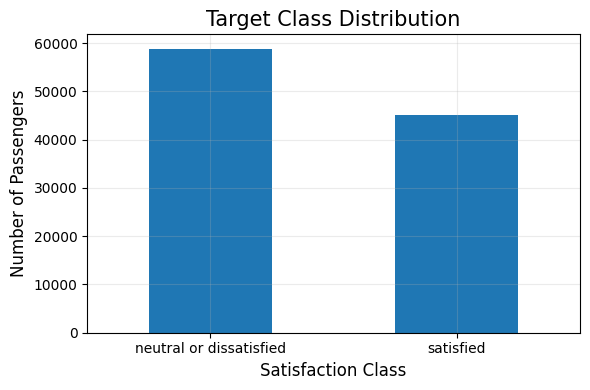

In [128]:
# Check how many passengers are in each satisfaction class

target_counts = data["satisfaction"].value_counts()
target_percentages = data["satisfaction"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Satisfaction Class": target_counts.index,
    "Count": target_counts.values,
    "Percentage": target_percentages.values.round(2)
})

display(target_summary)

# Bar chart for target variable

target_counts.plot(kind="bar", figsize=(6, 4))

plt.title("Target Class Distribution")
plt.xlabel("Satisfaction Class")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The target variable has two classes: **neutral or dissatisfied** and **satisfied**.

There are **58,879 neutral or dissatisfied passengers**, which is about **56.67%** of the dataset. There are **45,025 satisfied passengers**, which is about **43.33%** of the dataset.

This shows a small class imbalance, but it is not extremely large. Because of this, accuracy can still be useful, but I will also look at precision, recall, F1-score, and the confusion matrix later.

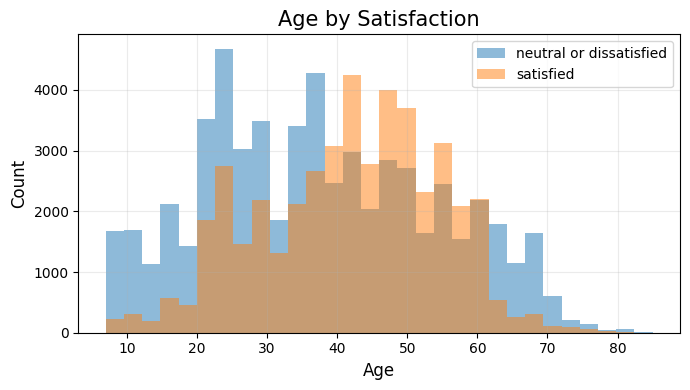

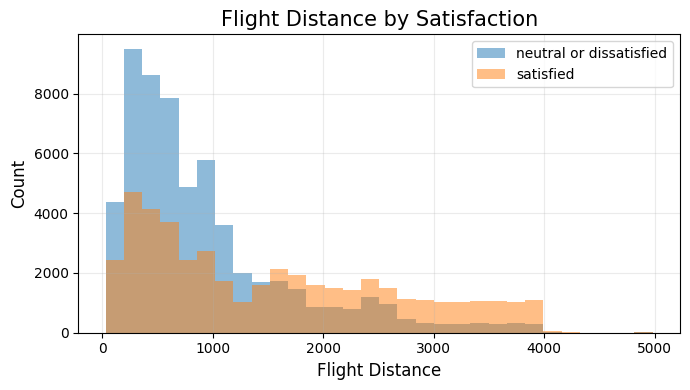

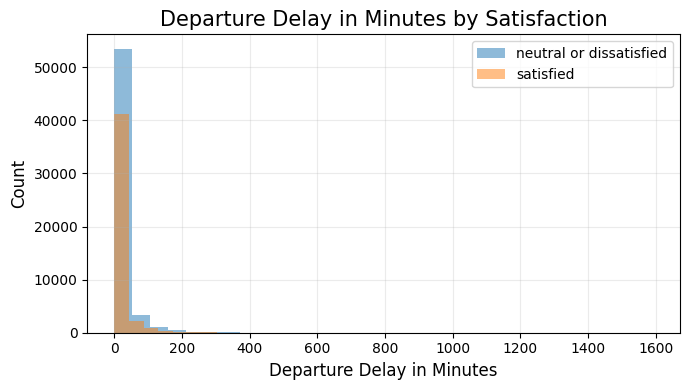

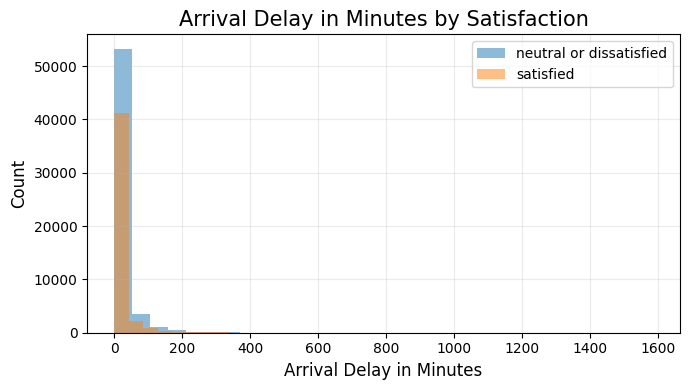

In [129]:
# Compare numerical features between the two satisfaction classes

numerical_features = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

for column in numerical_features:
    
    plt.figure(figsize=(7, 4))
    
    data[data["satisfaction"] == "neutral or dissatisfied"][column].hist(
        bins=30,
        alpha=0.5,
        label="neutral or dissatisfied"
    )
    
    data[data["satisfaction"] == "satisfied"][column].hist(
        bins=30,
        alpha=0.5,
        label="satisfied"
    )
    
    plt.title(column + " by Satisfaction")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Numerical Feature Distributions

These histograms compare important numerical features between the two satisfaction groups.

The features include **Age**, **Flight Distance**, **Departure Delay in Minutes**, and **Arrival Delay in Minutes**.

Some features show small differences between satisfied and neutral/dissatisfied passengers, but many of the distributions overlap. This means these features may help the model, but they are probably not strong enough to predict satisfaction by themselves.

The delay columns are also very skewed because most flights have small delays, while a smaller number of flights have very large delays.

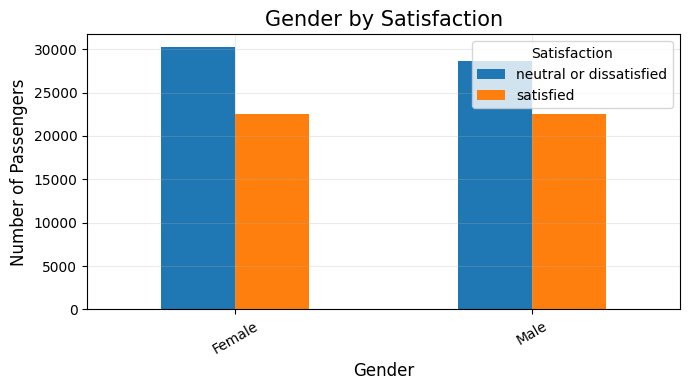

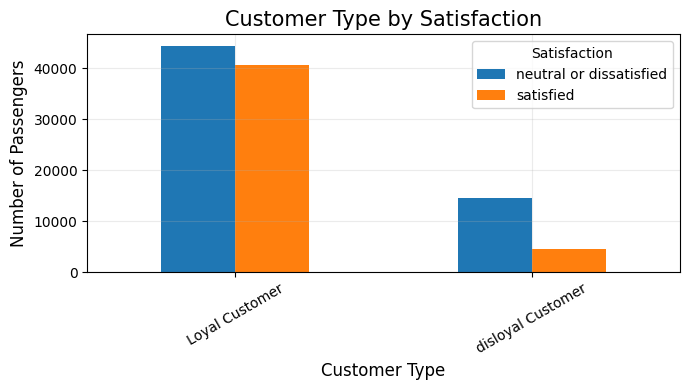

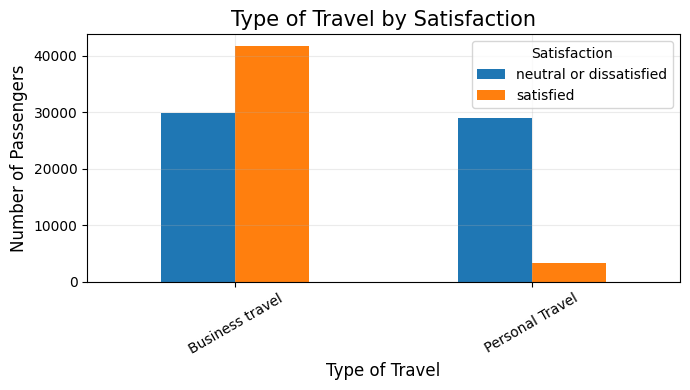

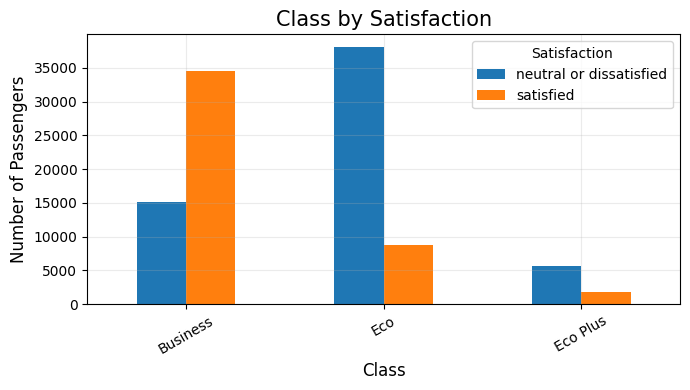

In [130]:
# Compare categorical features with satisfaction

categorical_features = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class"
]

for column in categorical_features:
    
    # Make a table comparing the feature with satisfaction
    table = pd.crosstab(data[column], data["satisfaction"])
    
    # Make a bar chart
    table.plot(kind="bar", figsize=(7, 4))
    
    plt.title(column + " by Satisfaction")
    plt.xlabel(column)
    plt.ylabel("Number of Passengers")
    plt.xticks(rotation=30)
    plt.legend(title="Satisfaction")
    plt.tight_layout()
    plt.show()

### Categorical Feature Distributions

These bar charts compare categorical features with the target variable **satisfaction**.

The charts show that **Gender** does not appear to have a very strong difference between satisfaction groups. However, **Customer Type**, **Type of Travel**, and **Class** show clearer patterns.

Business travelers and business class passengers appear more likely to be satisfied, while personal travel and economy passengers appear more likely to be neutral or dissatisfied.

In [131]:
# Compare average service ratings by satisfaction group

service_columns = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

# Find average service rating for each satisfaction group
service_means = data.groupby("satisfaction")[service_columns].mean()

# Find the difference between satisfied and neutral/dissatisfied passengers
service_difference = service_means.loc["satisfied"] - service_means.loc["neutral or dissatisfied"]

# Sort from biggest difference to smallest difference
service_difference = service_difference.sort_values(ascending=False)

service_difference

Online boarding                      1.371348
Inflight entertainment               1.070775
Seat comfort                         0.930235
On-board service                     0.838166
Leg room service                     0.831332
Cleanliness                          0.808219
Inflight wifi service                0.761655
Checkin service                      0.603089
Baggage handling                     0.590405
Inflight service                     0.580647
Food and drink                       0.563261
Ease of Online booking               0.484732
Gate location                        0.001758
Departure/Arrival time convenient   -0.158807
dtype: float64

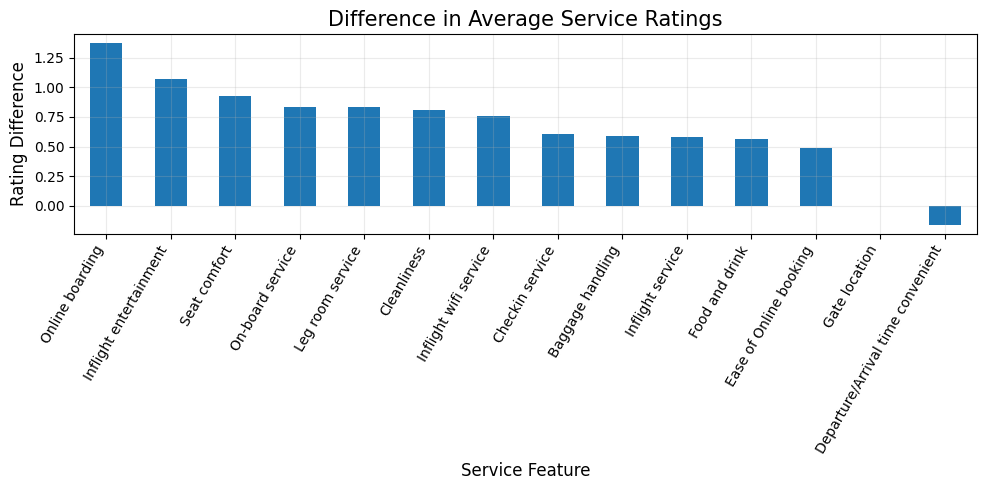

In [132]:
# Plot service rating differences

service_difference.plot(kind="bar", figsize=(10, 5))

plt.title("Difference in Average Service Ratings")
plt.xlabel("Service Feature")
plt.ylabel("Rating Difference")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

### Service Rating Difference

This chart shows the difference in average service ratings between satisfied passengers and neutral or dissatisfied passengers.

A larger difference means that the feature may be more useful for separating the two satisfaction groups.

The biggest differences appear in features such as **Online boarding**, **Inflight entertainment**, **Seat comfort**, **On-board service**, **Leg room service**, and **Cleanliness**. This suggests that service-related features are important for predicting passenger satisfaction.

## Visualization Summary

The visualizations show that passenger satisfaction is related to both travel information and service ratings.

The target variable has a small class imbalance, but it is not extreme. The numerical features show some patterns, but many of them overlap between the two satisfaction groups.

The categorical features show that **Customer Type**, **Type of Travel**, and **Class** are connected to satisfaction. The service rating features show some of the strongest differences, especially **Online boarding**, **Inflight entertainment**, **Seat comfort**, **On-board service**, **Leg room service**, and **Cleanliness**.

Based on these plots, service-related features seem important for the machine learning models.

## Data Cleaning and Preparation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

In [133]:
# Make a copy of the cleaned dataset for machine learning
machine_learning_data = data.copy()

# Check the columns before preparing the data
machine_learning_data.columns

Index(['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [134]:
# Check that there are no missing values before machine learning
machine_learning_data.isnull().sum().sum()

np.int64(0)

In [135]:
# Encode the target variable.
# neutral or dissatisfied = 0
# satisfied = 1

machine_learning_data["satisfaction_encoded"] = machine_learning_data["satisfaction"].map({
    "neutral or dissatisfied": 0,
    "satisfied": 1
})

# Check that the encoding worked
machine_learning_data[["satisfaction", "satisfaction_encoded"]]

,satisfaction,satisfaction_encoded
0,neutral or dissatisfied,0
1,neutral or dissatisfied,0
2,satisfied,1
3,neutral or dissatisfied,0
4,satisfied,1
...,...,...
103899,neutral or dissatisfied,0
103900,satisfied,1
103901,neutral or dissatisfied,0
103902,neutral or dissatisfied,0


In [136]:
# Separate the target variable.
# This is what the model will try to predict.

y = machine_learning_data["satisfaction_encoded"]


# Create the feature dataset.
# We remove:
# - satisfaction because it is the original text target
# - satisfaction_encoded because it is the target we are predicting
# - id because it is only an identification number, not a real feature

X = machine_learning_data.drop(columns=["satisfaction", "satisfaction_encoded", "id"])


# Check which categorical columns are still inside X.

categorical_columns = X.select_dtypes(include=["object"]).columns

categorical_columns

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class'], dtype='object')

In [137]:
# One-hot encode the categorical feature columns.
# This changes text categories into numeric 0/1 columns.

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)


# Check the new encoded dataset.

X_encoded.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,13,460,3,4,3,1,5,3,5,5,...,4,5,5,25,18.0,1,0,1,0,1
1,25,235,3,2,3,3,1,3,1,1,...,1,4,1,1,6.0,1,1,0,0,0
2,26,1142,2,2,2,2,5,5,5,5,...,4,4,5,0,0.0,0,0,0,0,0
3,25,562,2,5,5,5,2,2,2,2,...,1,4,2,11,9.0,0,0,0,0,0
4,61,214,3,3,3,3,4,5,5,3,...,3,3,3,0,0.0,1,0,0,0,0


In [138]:
print("Original feature shape:", X.shape)
print("Encoded feature shape:", X_encoded.shape)

Original feature shape: (103904, 22)
Encoded feature shape: (103904, 23)


In [139]:
# Check all columns after one-hot encoding
X_encoded.columns

Index(['Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'Gender_Male', 'Customer Type_disloyal Customer',
       'Type of Travel_Personal Travel', 'Class_Eco', 'Class_Eco Plus'],
      dtype='object')

## Data Preparation Summary

For machine learning, I made a copy of the cleaned dataset and encoded the target variable.

The target variable was changed into numbers:

- **0 = neutral or dissatisfied**
- **1 = satisfied**

Then I separated the data into **X** and **y**.

- **X** contains the features used to make predictions.
- **y** contains the target variable the model is trying to predict.

I removed the original **satisfaction** column, the new **satisfaction_encoded** column, and the **id** column from X. This prevents the model from using the answer or an ID number as a feature.

Finally, I used one-hot encoding to convert text columns like **Gender**, **Customer Type**, **Type of Travel**, and **Class** into numerical 0/1 columns.

The original feature dataset had **22 columns**, and after encoding, the dataset had **23 columns**. The final encoded dataset is ready for machine learning.

# Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


In [140]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (83123, 23)
X_test shape: (20781, 23)
y_train shape: (83123,)
y_test shape: (20781,)


In [141]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


### Feature Scaling

Feature scaling is important because the numerical features have very different ranges. For example, service ratings are usually between 0 and 5, while flight distance can go up to almost 5,000 and delay values can go over 1,000 minutes.

I used StandardScaler to rescale the features. StandardScaler changes the data so each feature has a mean close to 0 and a standard deviation close to 1.

I fitted the scaler only on the training data and then applied it to the test data. This prevents data leakage.

In [142]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model using scaled training data
logistic_model.fit(X_train_scaled, y_train)

# Make predictions on the test data
logistic_predictions = logistic_model.predict(X_test_scaled)

# Evaluate the model
logistic_accuracy = accuracy_score(y_test, logistic_predictions)

print("Logistic Regression Accuracy:", logistic_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_predictions))

print("\nClassification Report:")
print(classification_report(y_test, logistic_predictions))

Logistic Regression Accuracy: 0.8766180645782204

Confusion Matrix:
[[10637  1139]
 [ 1425  7580]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     11776
           1       0.87      0.84      0.86      9005

    accuracy                           0.88     20781
   macro avg       0.88      0.87      0.87     20781
weighted avg       0.88      0.88      0.88     20781



### Logistic Regression Results

The first machine learning model I used was Logistic Regression. This model was used as a baseline because the target variable has two classes: *neutral or dissatisfied* and *satisfied*.

The Logistic Regression model had an accuracy of about **87.66%**. This means the model correctly predicted the passenger satisfaction class for about 87.66% of the test data.

The confusion matrix was:

| Actual Class | Predicted 0 | Predicted 1 |
|---|---:|---:|
| Actual 0: neutral or dissatisfied | 10,637 | 1,139 |
| Actual 1: satisfied | 1,425 | 7,580 |

In this project:

- **0 = neutral or dissatisfied**
- **1 = satisfied**

The confusion matrix shows where the model was correct and where it made mistakes. The model correctly predicted **10,637** neutral or dissatisfied passengers and **7,580** satisfied passengers. This means the model made **18,217 correct predictions**.

The model incorrectly predicted **1,139** neutral or dissatisfied passengers as satisfied. It also incorrectly predicted **1,425** satisfied passengers as neutral or dissatisfied. This means the model made **2,564 incorrect predictions**.

The classification report shows that the model performed well for both classes. For class 0, the recall was **0.90**, meaning the model correctly found 90% of the neutral or dissatisfied passengers. For class 1, the recall was **0.84**, meaning the model correctly found 84% of the satisfied passengers.

Overall, Logistic Regression performed well as a baseline model. The model was slightly better at identifying neutral or dissatisfied passengers than satisfied passengers, but the precision, recall, and F1-scores were strong for both classes.

In [143]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the Decision Tree model.
# random_state keeps the result consistent every time the notebook runs.
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model.
# Decision Trees do not require scaled data, so I use X_train instead of X_train_scaled.
decision_tree_model.fit(X_train, y_train)

# Make predictions on the test data.
decision_tree_predictions = decision_tree_model.predict(X_test)

# Calculate accuracy.
decision_tree_accuracy = accuracy_score(y_test, decision_tree_predictions)

print("Decision Tree Accuracy:", decision_tree_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, decision_tree_predictions))

print("\nClassification Report:")
print(classification_report(y_test, decision_tree_predictions))

Decision Tree Accuracy: 0.9447572301621674

Confusion Matrix:
[[11146   630]
 [  518  8487]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     11776
           1       0.93      0.94      0.94      9005

    accuracy                           0.94     20781
   macro avg       0.94      0.94      0.94     20781
weighted avg       0.94      0.94      0.94     20781



### Decision Tree Results

The second machine learning model I used was a Decision Tree Classifier. Unlike Logistic Regression, a Decision Tree does not require scaled data, so I used the original training and testing feature sets.

The Decision Tree model had an accuracy of about **94.48%**, which is higher than the Logistic Regression accuracy of about **87.66%**.

The confusion matrix was:

| Actual Class | Predicted 0 | Predicted 1 |
|---|---:|---:|
| Actual 0: neutral or dissatisfied | 11,146 | 630 |
| Actual 1: satisfied | 518 | 8,487 |

In this project:

- **0 = neutral or dissatisfied**
- **1 = satisfied**

The model correctly predicted **11,146** neutral or dissatisfied passengers and **8,487** satisfied passengers. This means the model made **19,633 correct predictions**.

The model incorrectly predicted **630** neutral or dissatisfied passengers as satisfied. It also incorrectly predicted **518** satisfied passengers as neutral or dissatisfied. This means the model made **1,148 incorrect predictions**.

The classification report also shows strong results. For class 0, the recall was **0.95**, meaning the model correctly found 95% of the neutral or dissatisfied passengers. For class 1, the recall was **0.94**, meaning the model correctly found 94% of the satisfied passengers.

Overall, the Decision Tree performed better than Logistic Regression. This suggests that the relationship between passenger features and satisfaction may not be fully linear, and a tree-based model can capture more complex patterns in the data.

In [144]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions
random_forest_predictions = random_forest_model.predict(X_test)

# Calculate accuracy
random_forest_accuracy = accuracy_score(y_test, random_forest_predictions)

print("Random Forest Accuracy:", random_forest_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, random_forest_predictions))

print("\nClassification Report:")
print(classification_report(y_test, random_forest_predictions))


Random Forest Accuracy: 0.9620326259564025

Confusion Matrix:
[[11493   283]
 [  506  8499]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11776
           1       0.97      0.94      0.96      9005

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781



## Random Forest Results

The third machine learning model I used was a **Random Forest Classifier**. A Random Forest is similar to a Decision Tree, but instead of using only one tree, it builds many decision trees and combines their predictions.

This helps make the model more stable and usually reduces overfitting compared with a single Decision Tree.

The Random Forest model had an accuracy of about **96.20%**, which was higher than both the Logistic Regression model and the Decision Tree model.

The confusion matrix was:

| Actual Class | Predicted 0 | Predicted 1 |
|---|---:|---:|
| Actual 0: neutral or dissatisfied | 11,493 | 283 |
| Actual 1: satisfied | 506 | 8,499 |

In this project:

- **0 = neutral or dissatisfied**
- **1 = satisfied**

The model correctly predicted **11,493** neutral or dissatisfied passengers and **8,499** satisfied passengers. This means the model made **19,992 correct predictions**.

The model incorrectly predicted **283** neutral or dissatisfied passengers as satisfied. It also incorrectly predicted **506** satisfied passengers as neutral or dissatisfied. This means the model made **789 incorrect predictions**.

The classification report also shows strong results. For class 0, the recall was **0.98**, meaning the model correctly found 98% of the neutral or dissatisfied passengers. For class 1, the recall was **0.94**, meaning the model correctly found 94% of the satisfied passengers.

Overall, the Random Forest performed the best out of all three models. This suggests that combining many decision trees helped the model capture patterns in the dataset better than Logistic Regression or a single Decision Tree.

In [145]:
# Compare model accuracy scores

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.8766,
        decision_tree_accuracy,
        random_forest_accuracy
    ]
})

model_comparison["Accuracy Percentage"] = (
    model_comparison["Accuracy"] * 100
).round(2)

model_comparison

,Model,Accuracy,Accuracy Percentage
0,Logistic Regression,0.876600,87.66
1,Decision Tree,0.944757,94.48
2,Random Forest,0.962033,96.20


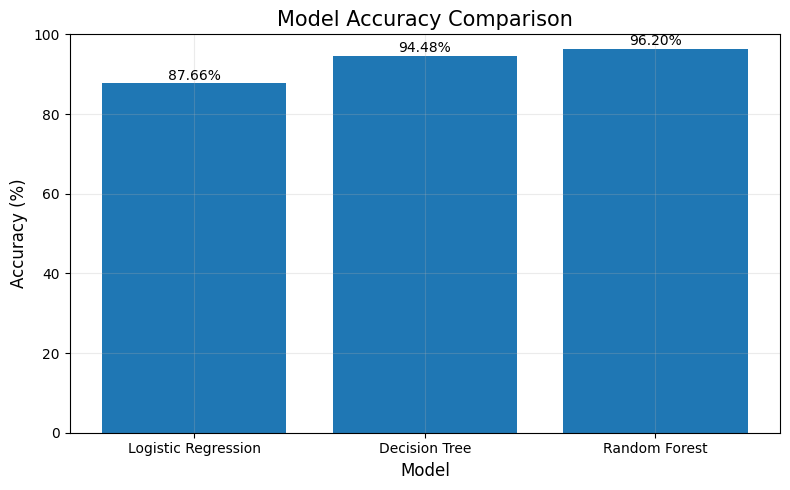

In [146]:
# Visualize the model comparison.

plt.figure(figsize=(8, 5))

bars = plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy Percentage"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Model Comparison Summary

I compared three machine learning models: **Logistic Regression**, **Decision Tree**, and **Random Forest**.

The Logistic Regression model achieved about **87.66% accuracy**. This was a strong baseline model, but it had the lowest accuracy out of the three models.

The Decision Tree model achieved about **94.48% accuracy**. This performed better than Logistic Regression, which suggests that the relationship between passenger features and satisfaction is not fully linear. A tree-based model can capture more complex patterns.

The Random Forest model achieved about **96.20% accuracy**, making it the best model in this project. Random Forest likely performed better because it combines many decision trees instead of relying on only one tree.

Overall, the Random Forest model was the strongest model for predicting airline passenger satisfaction.

## Feature Importance from the Random Forest

In [147]:
# Get feature importance values from the Random Forest model
# Higher values mean the feature was more important for making predictions.

rf_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort features from most important to least important
rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Show the top 10 most important features
rf_feature_importance.head(10)

,Feature,Importance
7,Online boarding,0.163464
2,Inflight wifi service,0.144893
20,Type of Travel_Personal Travel,0.103785
21,Class_Eco,0.078717
9,Inflight entertainment,0.053253
8,Seat comfort,0.046336
11,Leg room service,0.043446
1,Flight Distance,0.038386
19,Customer Type_disloyal Customer,0.037581
4,Ease of Online booking,0.037482


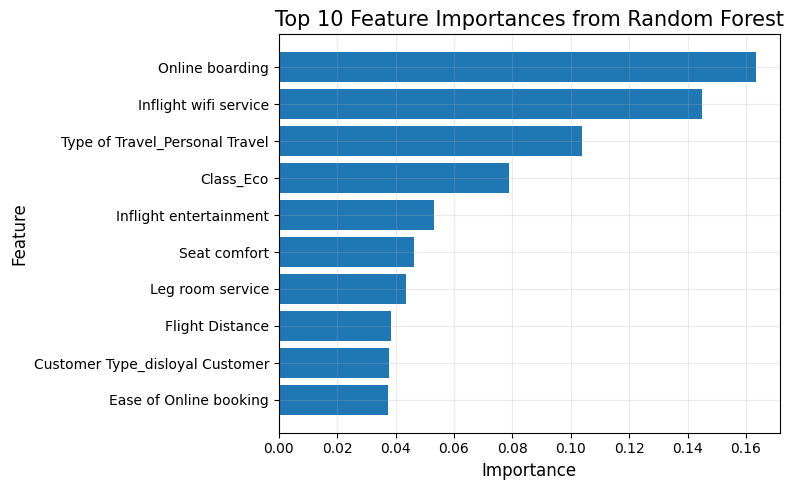

In [148]:
# Plot the top 10 most important features from the Random Forest model

top_rf_features = rf_feature_importance.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_rf_features["Feature"],
    top_rf_features["Importance"]
)

plt.title("Top 10 Feature Importances from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

# Put the most important feature at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Random Forest Feature Importance Summary

The Random Forest feature importance results show which variables were most useful for predicting passenger satisfaction.

The most important feature was **Online boarding**, which matches the visualization section where online boarding had the largest service rating difference between satisfied and neutral or dissatisfied passengers.

Other important features included **Inflight wifi service**, **Type of Travel**, **Class**, **Inflight entertainment**, **Seat comfort**, **Leg room service**, **Flight Distance**, **Customer Type**, and **Ease of Online booking**.

This is important because the machine learning results support the earlier visual analysis. Both the visualizations and the Random Forest model suggest that passenger satisfaction is strongly connected to online boarding, service quality, and travel-related features.

## Final Conclusion

This project used an airline passenger satisfaction dataset to predict whether passengers were **satisfied** or **neutral or dissatisfied**.

The visualizations showed that service-related features had strong associations with passenger satisfaction. In particular, **online boarding**, **inflight entertainment**, **seat comfort**, **on-board service**, **leg room service**, and **cleanliness** showed noticeable differences between satisfied and dissatisfied passengers.

The categorical visualizations also showed that **customer type**, **type of travel**, and **class** were important. Business class passengers and business travel passengers were more likely to be satisfied, while personal travel and economy class passengers were more likely to be neutral or dissatisfied.

After cleaning the data, filling missing arrival delay values, encoding categorical variables, splitting the data, and scaling numerical features, I trained three machine learning models: **Logistic Regression**, **Decision Tree**, and **Random Forest**.

The Logistic Regression model achieved about **87.66% accuracy**, the Decision Tree model achieved about **94.48% accuracy**, and the Random Forest model achieved about **96.20% accuracy**.

The Random Forest model performed the best. This makes sense because Random Forest combines many decision trees, which makes it more stable than a single Decision Tree and better able to capture complex patterns in the data.

The feature importance results supported the visualization findings because **online boarding** appeared as the most important feature. Overall, the results suggest that airlines should prioritize improving controllable service factors, especially **online boarding** and the overall **in-flight experience**, to improve passenger satisfaction.